# 6.0 Forecasting & Operations Overview

- This notebook focuses on predicting demand and aligning operations to support business performance.
- The objective is to estimate future revenue and order volume using historical patterns.
- Forecasting will be used to:
  - anticipate daily demand
  - support staffing decisions
  - improve operational planning
- Analysis will build on previously identified patterns:
  - strong peak-hour concentration
  - consistent daily demand trends
  - time-based customer behavior
- Python will be used for time-series modeling and visualization.
- The goal is to translate historical performance into forward-looking operational insight.

## 6.1 Forecasting Setup

- Reload the cleaned `orders_clean` fact table from the cleaned data layer.
- Create a daily time-series dataset from order-level transactions.
- Aggregate daily revenue, order count, guest volume, and AOV.
- Establish the daily grain needed for forecasting and operational planning.
- This setup keeps the forecasting notebook independent and reproducible.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Reconnect to DuckDB
con = duckdb.connect(database=':memory:')

# Reload cleaned dataset
con.execute("""
CREATE OR REPLACE TABLE orders_clean AS
SELECT * FROM read_csv_auto('data/cleaned/orders_clean.csv');
""")

# Create daily forecasting dataset
daily_forecast_df = con.execute("""
SELECT
    CAST(order_datetime AS DATE) AS order_date,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value,
    SUM(guest_count) AS total_guests
FROM orders_clean
GROUP BY CAST(order_datetime AS DATE)
ORDER BY order_date
""").fetchdf()

daily_forecast_df.head()

,order_date,total_orders,total_revenue,avg_order_value,total_guests
0,2024-09-04,93,1946.80,20.933333,125.0
1,2024-09-05,82,1841.13,22.452805,106.0
2,2024-09-06,94,2079.40,22.121277,119.0
3,2024-09-07,58,1534.51,26.457069,70.0
4,2024-09-08,76,2328.25,30.634868,127.0


## 6.2 Daily Revenue Trend Baseline

- Visualize daily revenue over time to establish a baseline demand pattern.
- Identify overall trend direction (growth, stability, or decline).
- Detect volatility, spikes, or unusual periods.
- This baseline serves as the foundation for building forecasting models.

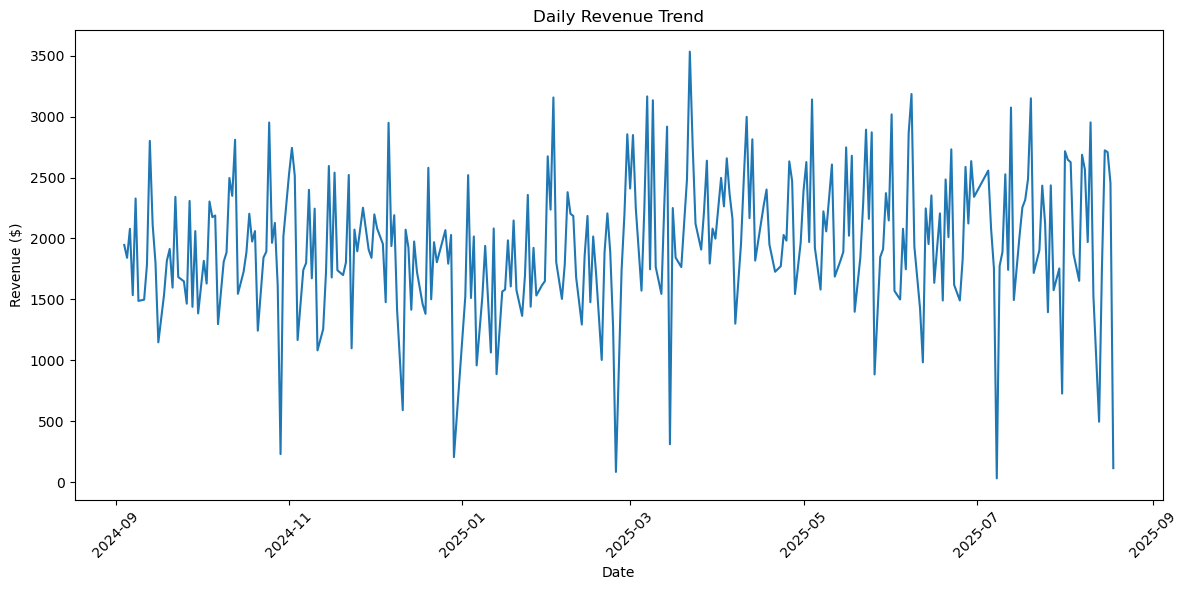

In [2]:
plt.figure(figsize=(12,6))
plt.plot(daily_forecast_df['order_date'], daily_forecast_df['total_revenue'])

plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6.3 Initial Trend Observations

- Daily revenue appears relatively stable with slight upward movement over time.
- Most daily revenue falls within the $1,500–$2,500 range, with occasional peaks exceeding $3,000.
- The data shows high day-to-day variability, indicating fluctuations in demand.
- Several near-zero revenue days are present, which likely represent anomalies such as closures, missing data, or partial operating days.
- A repeating pattern suggests potential weekly seasonality (weekday vs weekend effects).
- Due to volatility and anomalies, raw daily revenue is not suitable for direct forecasting without smoothing.

- This indicates that:
  - demand is consistent but variable
  - forecasting will require smoothing techniques (e.g., rolling averages)
  - anomaly handling may be necessary for accurate modeling

## 6.4 7-Day Rolling Average (Smoothed Trend)

- Apply a 7-day rolling average to smooth daily revenue fluctuations.
- This removes short-term noise and highlights the underlying trend.
- A 7-day window captures weekly seasonality (weekday vs weekend patterns).
- This serves as the baseline forecasting model for demand estimation.

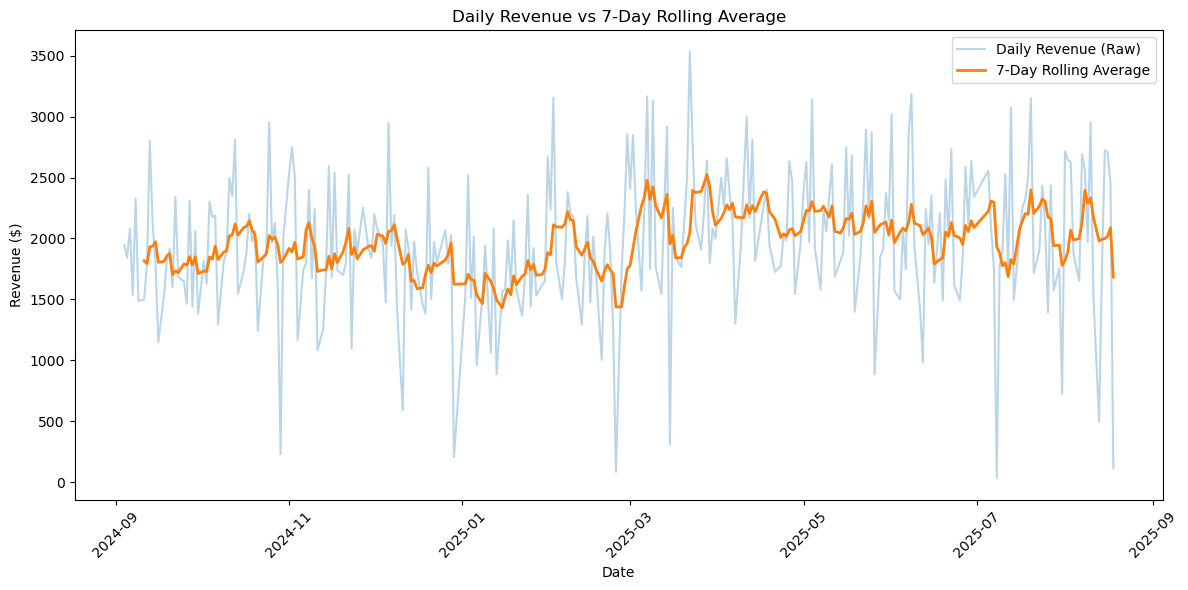

In [3]:
# Create 7-day rolling average
daily_forecast_df['revenue_7d_avg'] = (
    daily_forecast_df['total_revenue']
    .rolling(window=7)
    .mean()
)

# Plot raw vs smoothed
plt.figure(figsize=(12,6))

plt.plot(
    daily_forecast_df['order_date'],
    daily_forecast_df['total_revenue'],
    alpha=0.3,
    label='Daily Revenue (Raw)'
)

plt.plot(
    daily_forecast_df['order_date'],
    daily_forecast_df['revenue_7d_avg'],
    linewidth=2,
    label='7-Day Rolling Average'
)

plt.title('Daily Revenue vs 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6.5 Smoothed Trend Insights

- The 7-day rolling average reveals a clear and stable underlying revenue trend.
- Revenue shows a gradual upward movement over time, increasing from approximately $1,700–$1,900 to the $2,100–$2,400 range.
- This indicates consistent demand with moderate business growth.

- Daily volatility observed in the raw data is significantly reduced, confirming that fluctuations are largely short-term noise rather than structural changes.
- Several extreme spikes and near-zero days are smoothed out, suggesting these are anomalies (e.g., closures or data irregularities) rather than true demand signals.

- A repeating wave-like pattern is visible in the smoothed line, indicating weekly seasonality (likely weekday vs weekend behavior).
- This reinforces the presence of predictable demand cycles.

- Overall, the business demonstrates:
  - stable and predictable demand
  - moderate growth over time
  - manageable volatility once smoothed

- This smoothed trend provides a reliable baseline for forecasting and operational planning.

## 6.6 Forecast Projection (Baseline Model)

- Use the 7-day rolling average as a simple baseline forecast for near-term demand.
- This assumes recent trends and weekly patterns will continue.
- The goal is not perfect prediction, but a reliable directional estimate for planning.
- This forecast supports:
  - staffing decisions
  - inventory planning
  - operational readiness

In [4]:
# Create baseline forecast using last 7-day average
forecast_horizon = 14  # days ahead

last_date = daily_forecast_df['order_date'].max()
last_avg = daily_forecast_df['revenue_7d_avg'].iloc[-1]

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=forecast_horizon)

forecast_df = pd.DataFrame({
    'order_date': future_dates,
    'forecast_revenue': [last_avg] * forecast_horizon
})

forecast_df.head()

,order_date,forecast_revenue
0,2025-08-19,1683.054286
1,2025-08-20,1683.054286
2,2025-08-21,1683.054286
3,2025-08-22,1683.054286
4,2025-08-23,1683.054286


## 6.7 Forecast Visualization

- Visualize historical smoothed revenue alongside the projected forecast.
- Compare current performance with expected future demand.
- This helps contextualize the forecast relative to recent trends.

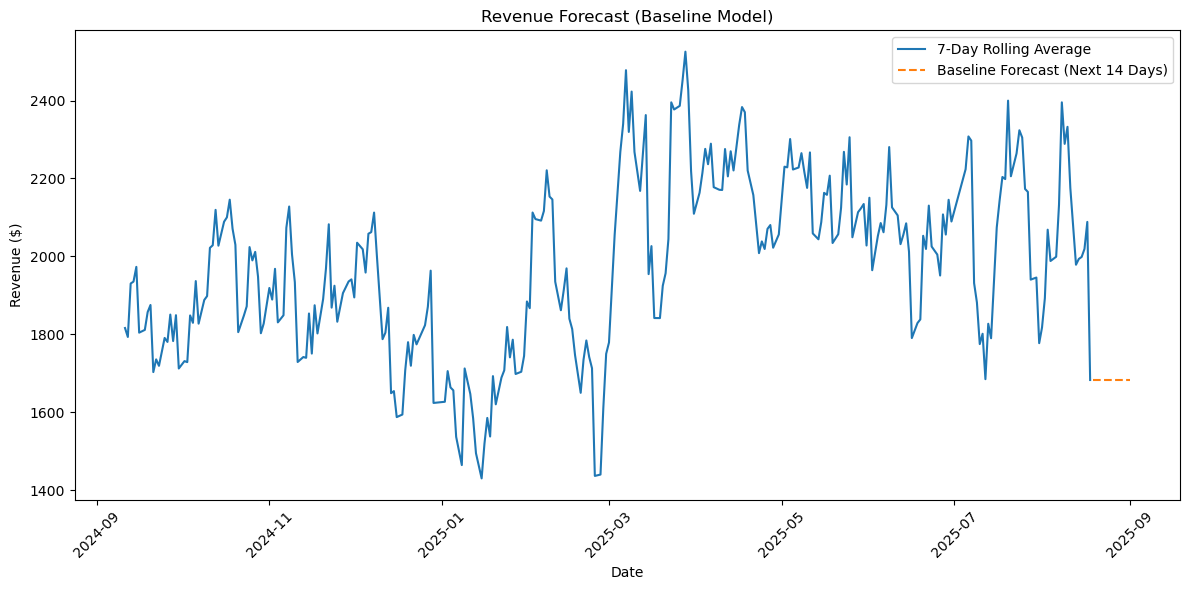

In [5]:
plt.figure(figsize=(12,6))

# Historical smoothed trend
plt.plot(
    daily_forecast_df['order_date'],
    daily_forecast_df['revenue_7d_avg'],
    label='7-Day Rolling Average'
)

# Forecast
plt.plot(
    forecast_df['order_date'],
    forecast_df['forecast_revenue'],
    linestyle='--',
    label='Baseline Forecast (Next 14 Days)'
)

plt.title('Revenue Forecast (Baseline Model)')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6.8 Forecast Interpretation

- The baseline forecast projects near-term revenue at approximately ~$1,680 per day based on the most recent 7-day rolling average.
- The forecast appears flat, reflecting the model assumption that recent performance will continue without major changes.

- Compared to the historical smoothed trend, the forecast is slightly lower than prior periods, indicating a recent short-term dip in performance.
- This suggests that the most recent days may have been weaker than the overall trend.

- The model captures:
  - recent performance more heavily than long-term growth
  - short-term fluctuations in demand
- It does not account for:
  - upward trend observed earlier in the data
  - weekly seasonality (weekday vs weekend variation)

- As a result, this forecast should be interpreted as:
  - a **conservative baseline estimate**
  - a **short-term planning reference**, not a long-term projection

- From an operational perspective:
  - staffing and preparation should align with this baseline level
  - deviations above or below this level may indicate demand shifts

- Future improvements to the model could include:
  - incorporating day-of-week effects
  - weighting longer-term trends
  - removing anomaly days from recent averages

## 6.9 Staffing Model (Revenue-Based)

- Translate forecasted demand into staffing requirements.
- Use revenue as a proxy for workload and labor needs.
- Establish a simple rule: revenue per staff member.
- This allows estimation of how many employees are needed per day.

- The goal is to align labor with expected demand while maintaining efficiency and service quality.

In [6]:
revenue_per_staff = 500  # adjustable assumption

forecast_df['required_staff'] = (
    forecast_df['forecast_revenue'] / revenue_per_staff
).round(1)

forecast_df

,order_date,forecast_revenue,required_staff
0,2025-08-19,1683.054286,3.4
1,2025-08-20,1683.054286,3.4
2,2025-08-21,1683.054286,3.4
3,2025-08-22,1683.054286,3.4
4,2025-08-23,1683.054286,3.4
5,2025-08-24,1683.054286,3.4
6,2025-08-25,1683.054286,3.4
7,2025-08-26,1683.054286,3.4
8,2025-08-27,1683.054286,3.4
9,2025-08-28,1683.054286,3.4


## 6.10 Staffing Requirement Projection

- Visualize estimated staffing needs based on forecasted revenue.
- Identify how many staff members are required per day.
- This helps align scheduling with expected demand levels.

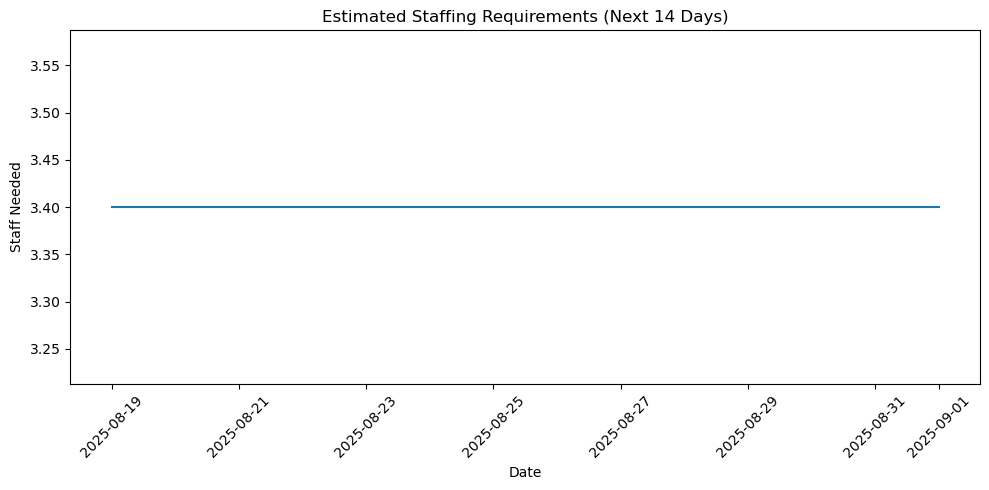

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    forecast_df['order_date'],
    forecast_df['required_staff']
)

plt.title('Estimated Staffing Requirements (Next 14 Days)')
plt.xlabel('Date')
plt.ylabel('Staff Needed')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6.11 Peak Staffing Model (Hour-Level Demand)

- Move from daily staffing estimates to hour-level staffing needs.
- Use historical order volume by hour as a proxy for operational workload.
- Identify which hours require higher staffing support.
- This improves on the flat daily staffing model by reflecting real demand variation across the day.
- The goal is to align labor more closely with peak operating pressure.

In [12]:
# Build hourly demand profile

hourly_staffing_df = con.execute("""
WITH hourly_orders AS (
    SELECT
        CAST(order_datetime AS DATE) AS order_date,
        EXTRACT(HOUR FROM order_datetime) AS order_hour,
        COUNT(*) AS orders_in_hour
    FROM orders_clean
    GROUP BY order_date, EXTRACT(HOUR FROM order_datetime)
)

SELECT
    order_hour,
    AVG(orders_in_hour) AS avg_orders_per_hour
FROM hourly_orders
GROUP BY order_hour
ORDER BY order_hour
""").fetchdf()

hourly_staffing_df

,order_hour,avg_orders_per_hour
0,9,1.000000
1,10,1.084746
2,11,13.244828
3,12,11.315972
4,13,6.414634
5,14,4.914591
6,15,5.754448
7,16,8.925532
8,17,11.432624
9,18,10.135714


## 6.12 Hour-Level Staffing Rules

- Translate hourly order volume into staffing requirements.
- Use a simple operational assumption:
  - 1 staff member can support approximately 20 orders per hour
- This creates a practical baseline for hourly labor planning.
- Staffing assumptions can be adjusted as real operational knowledge improves.

In [18]:
import numpy as np

orders_per_staff_per_hour = 5  # adjustable assumption

hourly_staffing_df['estimated_staff_needed'] = np.ceil(
    hourly_staffing_df['avg_orders_per_hour'] / orders_per_staff_per_hour
)

hourly_staffing_df

,order_hour,avg_orders_per_hour,estimated_staff_needed
0,9,1.000000,1.0
1,10,1.084746,1.0
2,11,13.244828,3.0
3,12,11.315972,3.0
4,13,6.414634,2.0
5,14,4.914591,1.0
6,15,5.754448,2.0
7,16,8.925532,2.0
8,17,11.432624,3.0
9,18,10.135714,3.0


## 6.13 Hour-Level Staffing Visualization

- Visualize estimated staffing needs by hour.
- Identify peak hours requiring the most support.
- Compare staffing needs across the business day to detect under- and over-staffed periods.

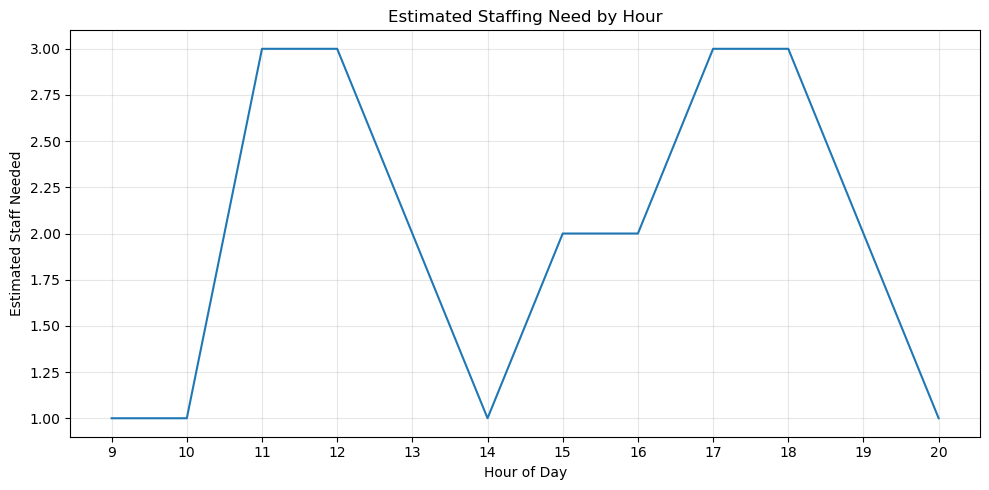

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly_staffing_df['order_hour'],
    hourly_staffing_df['estimated_staff_needed']
)

plt.title('Estimated Staffing Need by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Estimated Staff Needed')
plt.xticks(range(9,21))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6.14 Operational Staffing Insights

- Hour-level staffing analysis reveals clear demand-driven labor requirements throughout the day.
- Peak periods (11–12 and 17–18) require approximately 3 staff members to support higher order volume.
- Mid-level demand hours (15–16) require approximately 2 staff members.
- Off-peak hours (morning and late evening) can be efficiently managed with 1 staff member.

- This confirms that staffing needs are highly time-dependent and should not be modeled using flat daily assumptions.

- Compared to the earlier daily staffing model, which produced a constant requirement, the hour-level model provides a more accurate and operationally useful view of labor demand.

- Key operational implications:
  - prioritize staffing during lunch and dinner peaks
  - maintain minimal baseline staffing during low-demand hours
  - adjust staffing dynamically throughout the day to improve efficiency

- The analysis also highlights that staffing models are sensitive to efficiency assumptions.
- Calibrating the model to reflect realistic operational throughput was necessary to produce meaningful results.

- Overall, aligning staffing with hourly demand patterns can:
  - reduce labor costs during off-peak hours
  - improve service speed during peak hours
  - increase overall operational efficiency

## 6.15 SQL Demand & Operational Load Analysis

- Analyze order volume distribution to understand operational demand.
- Identify peak load periods that impact staffing and throughput.
- Translate demand patterns into operational insights.

In [1]:
import pandas as pd
import duckdb

# ==============================
# Step 1: Load cleaned dataset
# ==============================

orders_clean = pd.read_csv("../data/cleaned/orders_clean.csv")

# restore datetime (CSV limitation)
orders_clean["order_datetime"] = pd.to_datetime(orders_clean["order_datetime"])

# ==============================
# Step 2: DuckDB connection
# ==============================

con = duckdb.connect()
con.register("orders_clean", orders_clean)

# ==============================
# Step 3: SQL Demand Distribution
# ==============================

con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS orders_per_hour
FROM orders_clean
GROUP BY order_hour
ORDER BY order_hour
""").fetchdf()

,order_hour,orders_per_hour
0,9,1
1,10,64
2,11,3841
3,12,3259
4,13,1841
5,14,1381
6,15,1617
7,16,2517
8,17,3224
9,18,2838


In [2]:
con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS orders_per_hour,
    SUM(order_total) AS total_revenue,
    ROUND(AVG(order_total), 2) AS avg_order_value
FROM orders_clean
GROUP BY order_hour
ORDER BY order_hour
""").fetchdf()

,order_hour,orders_per_hour,total_revenue,avg_order_value
0,9,1,5.25,5.25
1,10,64,1024.07,16.00
2,11,3841,92533.05,24.09
3,12,3259,86567.47,26.56
4,13,1841,42734.53,23.21
5,14,1381,32313.08,23.40
6,15,1617,40481.66,25.04
7,16,2517,66872.10,26.57
8,17,3224,90153.19,27.96
9,18,2838,81880.89,28.85
